# Clustering

In [14]:
from sklearn.datasets import load_digits
import numpy as np

digits = load_digits()
data, labels = load_digits(return_X_y=True)
n_digits = len(np.unique(labels))

## K Means

In [15]:
class KMeans:
    def __init__(self, k_clusters = 10, iterations = 100):
        self.iterations = iterations
        self.k_clusters = k_clusters
        self.centroid_function = np.mean

    def fit(self, X, y=None):
        num_samples, _ = X.shape
        # Randomly select {k_clusters} number of samples from X to be our starting cluster centers
        random_sample_indexes = np.random.randint(0, num_samples, size=self.k_clusters)
        self.cluster_centers_ = X[random_sample_indexes]

        self.labels_ = self.get_labels(X, num_samples)
        self.starting_inertia_ = self.get_inertia(X)

        for _ in range(self.iterations):
            # Label each sample with its closest cluster center
            labels = self.get_labels(X, num_samples)

            old_cluster_centers = np.copy(self.cluster_centers_)
            # For each cluster, find the mean of the samples in that cluster
            # This is the new centroid of the cluster
            self.cluster_centers_ = np.array([self.centroid_function(X[labels == cluster_idx], axis=0) for cluster_idx in range(self.k_clusters)])

            # No need to continue if none of the centroids are being updated anymore
            if np.array_equal(self.cluster_centers_, old_cluster_centers):
                break

        self.labels_ = self.get_labels(X, num_samples)
        self.inertia_ = self.get_inertia(X)

    def get_labels(self, X, num_samples):
        labels = np.empty(num_samples, dtype=int)
        # For each sample, find the closest centroid
        for sample_idx in range(num_samples):
            distances = np.linalg.norm(self.cluster_centers_ - X[sample_idx], axis=1)
            closest_centroid = np.argmin(distances)
            labels[sample_idx] = closest_centroid
        return labels

    def get_inertia(self, X):
        distances = np.linalg.norm(X - self.cluster_centers_[self.labels_], axis=1)
        return np.sum(distances ** 2)

    def predict(self, X_test):
        return self.get_labels(X_test, X_test.shape[0])


## K Medoids

In [16]:
class KMedoids(KMeans):
    # The medoid of a cluster is the centroid
    def centroid_function(self, cluster, axis=None):
        # Find the sample with the smallest total distance to every other sample in the cluster
        distance_sums = [np.sum([np.linalg.norm(medoid - sample) for sample in cluster]) for medoid in cluster]
        return cluster[np.argmin(distance_sums)]

    def get_inertia(self, X):
        distances = np.linalg.norm(X - self.cluster_centers_[self.labels_], axis=1)
        return np.sum(distances)

# Benching and plotting code was found here:
### [A demo of K-Means clustering on the handwritten digits data](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_digits.html#sphx-glr-auto-examples-cluster-plot-kmeans-digits-py)
### [A demo of K-Medoids clustering on the handwritten digits data](https://scikit-learn-extra.readthedocs.io/en/stable/auto_examples/cluster/plot_kmedoids_digits.html#sphx-glr-auto-examples-cluster-plot-kmedoids-digits-py)

In [17]:
from time import time

from sklearn import metrics
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def bench_k_means(kmeans, name, data, labels):
    """Benchmark to evaluate the KMeans initialization methods.

    Parameters
    ----------
    kmeans : KMeans instance
        A :class:`~sklearn.cluster.KMeans` instance with the initialization
        already set.
    name : str
        Name given to the strategy. It will be used to show the results in a
        table.
    data : ndarray of shape (n_samples, n_features)
        The data to cluster.
    labels : ndarray of shape (n_samples,)
        The labels used to compute the clustering metrics which requires some
        supervision.
    """
    t0 = time()
    estimator = make_pipeline(StandardScaler(), kmeans).fit(data)
    fit_time = time() - t0
    results = [name, fit_time, estimator[-1].inertia_]

    # Define the metrics which require only the true labels and estimator
    # labels
    clustering_metrics = [
        metrics.homogeneity_score,
        metrics.completeness_score,
        metrics.v_measure_score,
        metrics.adjusted_rand_score,
        metrics.adjusted_mutual_info_score,
    ]
    results += [m(labels, estimator[-1].labels_) for m in clustering_metrics]

    # The silhouette score requires the full dataset
    results += [
        metrics.silhouette_score(
            data,
            estimator[-1].labels_,
            metric="euclidean",
            sample_size=300,
        )
    ]

    # Show the results
    formatter_result = (
        "{:18s}\t{:.3f}s\t{:.0f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}"
    )
    print(formatter_result.format(*results))

In [18]:
from sklearn.cluster import KMeans as KMeansSKLearn
from sklearn_extra.cluster import KMedoids as KMedoidsSKLearn

# K Means from sklearn
kmeansSKLearn = KMeansSKLearn(n_clusters=n_digits, random_state=0, n_init=10, init="random")

# K Means from Scratch
kmeans = KMeans(k_clusters=n_digits)

# K Medoids from sklearn
kmedoidsSKLearn = KMedoidsSKLearn(metric="euclidean", n_clusters=n_digits)

# K Medoids from Scratch
kmedoids = KMedoids(k_clusters=n_digits)


print(90 * "_")
print("init\t\t\ttime\tinertia\thomo\tcompl\tv-meas\tARI\tAMI\tsilhouette")
bench_k_means(kmeans=kmeansSKLearn, name="k-means++", data=data, labels=labels)
bench_k_means(kmeans=kmeans, name="KMeans Scratch", data=data, labels=labels)
bench_k_means(kmeans=kmedoidsSKLearn, name="k-medoids", data=data, labels=labels)
bench_k_means(kmeans=kmedoids, name="KMedoids Scratch", data=data, labels=labels)
print(90 * "_")

__________________________________________________________________________________________
init			time	inertia	homo	compl	v-meas	ARI	AMI	silhouette
k-means++         	0.070s	69707	0.675	0.716	0.694	0.560	0.691	0.174


KMeans Scratch    	0.496s	71745	0.664	0.688	0.676	0.539	0.673	0.152
k-medoids         	0.050s	11779	0.555	0.564	0.559	0.452	0.555	0.128
KMedoids Scratch  	0.345s	10371	0.573	0.643	0.606	0.453	0.602	0.109
__________________________________________________________________________________________


In [21]:
print("K Means Inertia")
print(f"Starting: {kmeans.starting_inertia_:.2f}")
print(f"Ending: {kmeans.inertia_:.2f}")
print()
print("K Medoids Inertia")
print(f"Starting: {kmedoids.starting_inertia_:.2f}")
print(f"Ending: {kmedoids.inertia_:.2f}")

K Means Inertia
Starting: 118021.13
Ending: 71744.97

K Medoids Inertia
Starting: 13273.44
Ending: 10371.20


#### We can see that both methods reduce clustering loss because their inertia decreases over time.

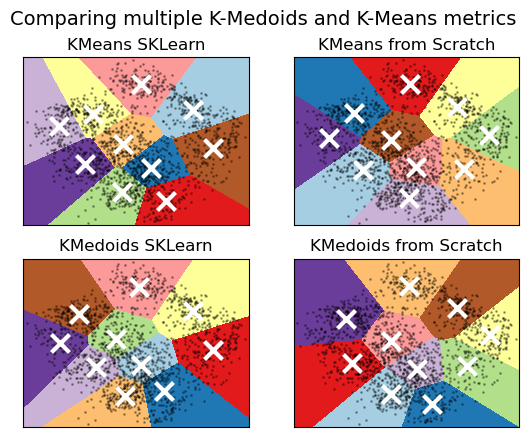

In [20]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

reduced_data = PCA(n_components=2).fit_transform(data)

# Step size of the mesh. Decrease to increase the quality of the VQ.
h = 0.02  # point in the mesh [x_min, m_max]x[y_min, y_max].

# Plot the decision boundary. For that, we will assign a color to each
x_min, x_max = reduced_data[:, 0].min() - 1, reduced_data[:, 0].max() + 1
y_min, y_max = reduced_data[:, 1].min() - 1, reduced_data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

plt.figure()
plt.clf()

plt.suptitle(
    "Comparing multiple K-Medoids and K-Means metrics",
    fontsize=14,
)


selected_models = [
    (KMeansSKLearn(n_clusters=n_digits, random_state=0, n_init=10, init="random"), "KMeans SKLearn"),
    (KMeans(k_clusters=n_digits),                                                  "KMeans from Scratch"),
    (KMedoidsSKLearn(metric="euclidean", n_clusters=n_digits),                     "KMedoids SKLearn"),
    (KMedoids(k_clusters=n_digits),                                                "KMedoids from Scratch"),
]

plot_rows = int(np.ceil(len(selected_models) / 2.0))
plot_cols = 2

for i, (model, description) in enumerate(selected_models):
    # Obtain labels for each point in mesh. Use last trained model.
    model.fit(reduced_data)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.subplot(plot_cols, plot_rows, i + 1)
    plt.imshow(
        Z,
        interpolation="nearest",
        extent=(xx.min(), xx.max(), yy.min(), yy.max()),
        cmap=plt.cm.Paired,
        aspect="auto",
        origin="lower",
    )

    plt.plot(
        reduced_data[:, 0], reduced_data[:, 1], "k.", markersize=2, alpha=0.3
    )
    # Plot the centroids as a white X
    centroids = model.cluster_centers_
    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker="x",
        s=169,
        linewidths=3,
        color="w",
        zorder=10,
    )
    plt.title(description)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xticks(())
    plt.yticks(())

plt.show()